1. concat([df1 , df2], ignore_index = True)
2. concat([df1, df2] , keys = ["df1_name", "df2_name"])
3. append() --> deplicating 
4. df1.merge(df2 , how ="inner / outer /left / right " on = "column_name")
5. pd.merge(students , regis , how = 'inner', on = 'student_id')
6. 'full' is not a valid Merge type: left, right, inner, outer, left_anti, right_anti, cross, asof
7. np.intersect1d(df1['col1'], df2['col1'])
8. np.setdiff1(df1['col1'], df2['col1'])
9. df1.merge(df1 , how = 'inner', left_on = 'partner', right_on = 'student_id')[['name_x','name_y']].head()

In [81]:
import numpy as np 
import pandas as pd

In [123]:
courses = pd.read_csv(r"C:\Users\HOME\Downloads\courses.csv")
students = pd.read_csv(r"C:\Users\HOME\Downloads\students (1).csv")
nov = pd.read_csv(r"C:\Users\HOME\Downloads\reg-month1.csv")
dec = pd.read_csv(r"C:\Users\HOME\Downloads\reg-month2.csv")
matches = pd.read_csv(r"C:\Users\HOME\Downloads\matches.csv")
delivery = pd.read_csv(r"C:\Users\HOME\Downloads\deliveries.csv")
ipl1 = pd.read_csv(r"C:\Users\HOME\Downloads\deliveries.csv")

In [124]:
regis = pd.concat([nov,dec], ignore_index = True)
regis = pd.concat([nov , dec] , keys = ['nov' , 'dec']) # multi dataframe 

In [125]:
regis.loc['nov'].head(2)

,student_id,course_id
0,23,1
1,15,5


In [126]:
regis.loc['dec',4]

student_id    14
course_id      9
Name: (dec, 4), dtype: int64

In [127]:
pd.concat([nov,dec], axis = 1).head()

,student_id,course_id,student_id,course_id
0,23.0,1.0,3,5
1,15.0,5.0,16,7
2,18.0,6.0,12,10
3,23.0,4.0,12,1
4,16.0,9.0,14,9


In [128]:
# inner join 
students.merge(regis,how ="inner", on = "student_id").head()

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5


In [129]:
# left join 
courses.merge(regis , how = "left", on = "course_id" ).tail()

,course_id,course_name,price,student_id
50,10,pyspark,2499,17.0
51,10,pyspark,2499,1.0
52,10,pyspark,2499,11.0
53,11,Numpy,699,NaN
54,12,C++,1299,NaN


In [130]:
# right join 
courses.merge(regis , how = "right", on  = "course_id").tail()

,course_id,course_name,price,student_id
48,1,python,2499,14
49,10,pyspark,2499,11
50,9,plotly,699,42
51,8,pandas,1099,50
52,1,python,2499,38


In [131]:
# outer join / full join :
courses.merge(regis , how = "inner", on  = "course_id").tail()

,course_id,course_name,price,student_id
48,10,pyspark,2499,25
49,10,pyspark,2499,12
50,10,pyspark,2499,17
51,10,pyspark,2499,1
52,10,pyspark,2499,11


In [132]:
# find the total revenve generated :
courses.merge(regis , how = "inner", on  = "course_id")['price'].sum()

np.int64(154247)

In [133]:
#  find the monthly month revenue :
temp_df = pd.concat([nov , dec] , keys =['nov', 'dec']).reset_index()
temp_df.merge(courses , on = "course_id").groupby('level_0')['price'].sum()

level_0
dec    65072
nov    89175
Name: price, dtype: int64

In [134]:
temp_df = pd.concat([nov , dec] , keys =['nov', 'dec']).reset_index()
temp_df.head()

,level_0,level_1,student_id,course_id
0,nov,0,23,1
1,nov,1,15,5
2,nov,2,18,6
3,nov,3,23,4
4,nov,4,16,9


In [135]:
#  print the registration table :
regis.merge(students , on = 'student_id').merge(courses, on = 'course_id')[['name','course_name', 'price']]

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


<Axes: xlabel='course_name'>

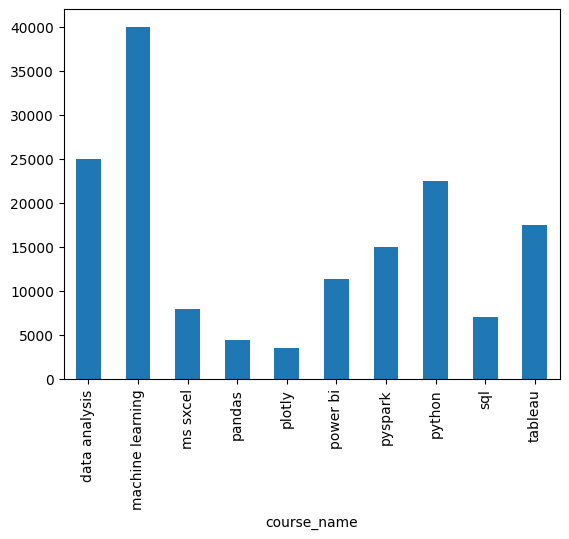

In [136]:
# plot a bar chart for revenue / corses
regis.merge(courses , on = 'course_id').groupby('course_name')['price'].sum().plot(kind = 'bar')

In [137]:
# Find the students who enrolled in both the month 

In [138]:
common_student_id = np.intersect1d(nov['student_id'], dec['student_id'])

In [139]:
common_student_id

array([ 1,  3,  7, 11, 16, 17, 18, 22, 23])

In [140]:
students[students['student_id'].isin(common_student_id)]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [141]:
# Find courses that got not enrolled :
diff_course_id = np.setdiff1d(courses['course_id'], regis['course_id'])

In [142]:
courses[courses.course_id.isin([diff_course_id])]

,course_id,course_name,price


In [143]:
# Use == when filtering for a single value
courses[courses.course_id == 'diff_course_id']


,course_id,course_name,price


In [144]:
#  find the students ho did not enroll into any courses

In [145]:
courses.columns

Index(['course_id', 'course_name', 'price'], dtype='str')

In [146]:
students.columns

Index(['student_id', 'name', 'partner'], dtype='str')

In [147]:
regis.columns

Index(['student_id', 'course_id'], dtype='str')

In [148]:
students_not_enrolled = np.setdiff1d(students['student_id'], regis['student_id'])

In [149]:
students[students.student_id.isin(students_not_enrolled )]

,student_id,name,partner
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8
19,20,Hanuman Hegde,11


In [150]:
# print student name --> parteners name for all enrolled students 
students.merge(students , how = 'inner', left_on = 'partner', right_on = 'student_id')[['name_x','name_y']].head()

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor


In [151]:
# find the top 3 students who did most number enrollments :
students.merge(regis, how = 'inner',  on = 'student_id'  ).groupby('name')['name'].count().sort_values(ascending = False )

name
Chhavi Lachman        6
Tarun Thaker          5
Radha Dutt            4
Elias Dodiya          4
Pranab Natarajan      4
Kailash Harjo         4
David Mukhopadhyay    3
Yash Sethi            3
Fardeen Mahabir       3
Preet Sha             2
Shashank D’Alia       2
Yasmin Palan          2
Parveen Bhalla        2
Qabeel Raman          2
Munni Varghese        1
Esha Butala           1
Seema Kota            1
Radhika Suri          1
Name: name, dtype: int64

In [152]:
# Alternate syntax of merge :
pd.merge(students , regis , how = 'inner', on = 'student_id').head()

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5


In [153]:
# ipl problems :: --> use -> match , delivery dataframe 

# 1. find the top 3 stadium with highest sixes / match ratio :


In [159]:
matches.shape

(636, 18)

In [160]:
ipl1.shape

(179078, 21)

In [161]:
tempdf = ipl1.merge(matches , left_on = 'match_id', right_on = 'id')

In [162]:
tempdf.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder', 'id', 'season', 'city', 'date', 'team1',
       'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied',
       'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue',
       'umpire1', 'umpire2', 'umpire3'],
      dtype='str')

In [175]:
con1 = tempdf[tempdf.batsman_runs == 6 ]
num_matches = matches['venue'].value_counts()

In [176]:
nums_six = con1.groupby('venue')['venue'].count()

In [180]:
(num_matches / nums_six).sort_values(ascending = False).head(5)

venue
OUTsurance Oval                                     0.250000
Sheikh Zayed Stadium                                0.175000
Shaheed Veer Narayan Singh International Stadium    0.136364
Sawai Mansingh Stadium                              0.135802
Nehru Stadium                                       0.128205
dtype: float64

In [195]:
# find the orange cap holder of all the seasons
s = tempdf.groupby(['batsman' ,  'season'])['batsman_runs'].sum().reset_index().sort_values('batsman_runs',ascending = False).drop_duplicates(subset = ['season'], keep = 'first').sort_values('season', ascending = True)

In [196]:
s

,batsman,season,batsman_runs
1237,SE Marsh,2008,616
834,ML Hayden,2009,572
1306,SR Tendulkar,2010,618
272,CH Gayle,2011,608
273,CH Gayle,2012,733
795,MEK Hussey,2013,733
1142,RV Uthappa,2014,660
324,DA Warner,2015,562
1433,V Kohli,2016,973
326,DA Warner,2017,641


In [197]:
tempdf.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder', 'id', 'season', 'city', 'date', 'team1',
       'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied',
       'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue',
       'umpire1', 'umpire2', 'umpire3'],
      dtype='str')